In [38]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [18]:
df = pd.read_csv("Fish.csv")
df.shape

(159, 7)

In [19]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [20]:
# nulos?
"...sin nulos"
df.apply(lambda x: x.isnull().sum())


Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [21]:
"""
1. Crea una nueva columna que incluya el volumen de pez, asumiéndolo como un
cilindro. Para un cilindro con una base circular, el área de la base (A) es igual a πr²,
donde "r" es el radio de la base del cilindro, y la altura (h) es la distancia entre las dos
bases circulares.
"""
df['volumen_pez'] = (math.pi*(df['Width']/2)**2)*df['Height']
df

,Species,Weight,Length1,Length2,Length3,Height,Width,volumen_pez
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,146.215854
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,181.707071
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,214.391723
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,198.477454
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,257.609344
...,...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936,3.188567
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690,3.073402
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558,2.820291
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672,9.641848


<Axes: >

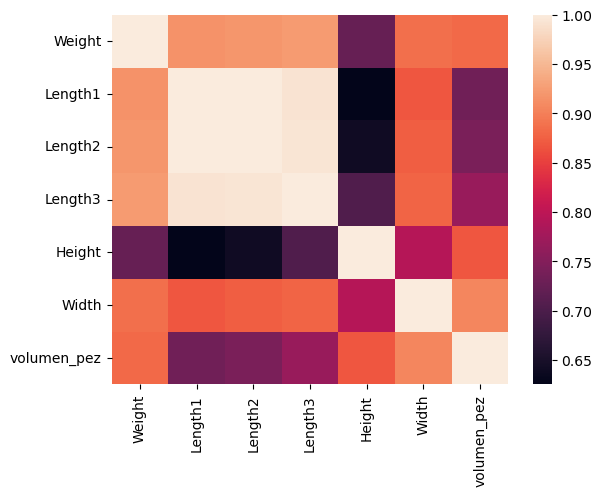

In [24]:
"""
2. Verifica la correlación posible entre las variables, numérica y gráficamente.
¿Aumenta la correlación entre el peso y longitudes de los peces, altura y ancho al
añadir el volumen? Explica
"""
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

In [25]:
corr

,Weight,Length1,Length2,Length3,Height,Width,volumen_pez
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507,0.881981
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050,0.732409
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547,0.741313
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520,0.767774
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881,0.868256
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000,0.905626
volumen_pez,0.881981,0.732409,0.741313,0.767774,0.868256,0.905626,1.000000


Ecuación de la recta: Peso = 1.7396 * Volumen + (58.7401)
Coeficiente de Determinación (R²): 0.7779
Raíz del Error Cuadrático Medio (RMSE): 168.1782


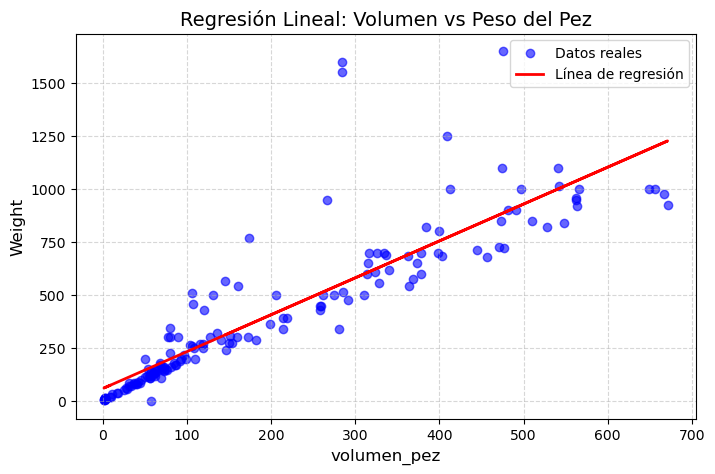

In [29]:
"""
3. Construye un modelo de regresión lineal que relacione el volumen y el peso de los
peces. Realiza una breve evaluación del modelo y grafícalo.
"""

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Definir las variables
# NOTA: Ajusta 'Volumen' y 'Peso' según el nombre exacto de tus columnas
X = df[['volumen_pez']]  # Debe ir con doble corchete para que sea un DataFrame de 2D
y = df['Weight']       # Serie 1D

# 2. Crear y entrenar el modelo de Regresión Lineal
modelo = LinearRegression()
modelo.fit(X, y)

# 3. Realizar predicciones
y_pred = modelo.predict(X)

# 4. Obtener coeficientes y métricas de evaluación
intercepto = modelo.intercept_
pendiente = modelo.coef_[0]
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# Imprimir resultados
print(f"Ecuación de la recta: Peso = {pendiente:.4f} * Volumen + ({intercepto:.4f})")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")

# 5. Graficar el modelo
plt.figure(figsize=(8, 5))

# Puntos reales
plt.scatter(df['volumen_pez'], df['Weight'], color='blue', alpha=0.6, label='Datos reales')

# Línea de regresión
plt.plot(df['volumen_pez'], y_pred, color='red', linewidth=2, label='Línea de regresión')

plt.title('Regresión Lineal: Volumen vs Peso del Pez', fontsize=14)
plt.xlabel('volumen_pez', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
"""
El modelo lineal captura adecuadamente la tendencia ascendente general. Sin embargo, debido a la mayor 
dispersión en valores altos (heterocedasticidad), el uso de una regresión lineal ofrece menor precision.
"""

In [33]:
"""
4. ¿Qué sucede si aplicas el modelo anterior por separado a cada especie de peces?
Explica.
"""
especies = df['Species'].unique()

for especie in especies:
    # Filtrar el dataframe por especie
    df_especie = df[df['Species'] == especie]
    
    # Definir variables X e y
    X = df_especie[['volumen_pez']]
    y = df_especie['Weight']
    
    # Crear y entrenar el modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Predicciones y métricas
    y_pred = modelo.predict(X)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Imprimir resultados por especie
    print(f"Especie: {especie}")
    print(f"  Ecuación: Peso = {modelo.coef_[0]:.4f} * Volumen + ({modelo.intercept_:.4f})")
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print("-" * 50)

Especie: Bream
  Ecuación: Peso = 1.3835 * Volumen + (108.1896)
  R²: 0.8977
  RMSE: 65.9420
--------------------------------------------------
Especie: Roach
  Ecuación: Peso = 1.8276 * Volumen + (10.4907)
  R²: 0.8885
  RMSE: 28.9108
--------------------------------------------------
Especie: Whitefish
  Ecuación: Peso = 1.9707 * Volumen + (18.3115)
  R²: 0.8604
  RMSE: 105.5821
--------------------------------------------------
Especie: Parkki
  Ecuación: Peso = 1.7755 * Volumen + (12.1823)
  R²: 0.9955
  RMSE: 5.0585
--------------------------------------------------
Especie: Perch
  Ecuación: Peso = 1.7580 * Volumen + (34.9744)
  R²: 0.9677
  RMSE: 61.9353
--------------------------------------------------
Especie: Pike
  Ecuación: Peso = 3.6777 * Volumen + (60.6655)
  R²: 0.8424
  RMSE: 190.3219
--------------------------------------------------
Especie: Smelt
  Ecuación: Peso = 1.6270 * Volumen + (5.5697)
  R²: 0.8780
  RMSE: 1.3903
----------------------------------------------

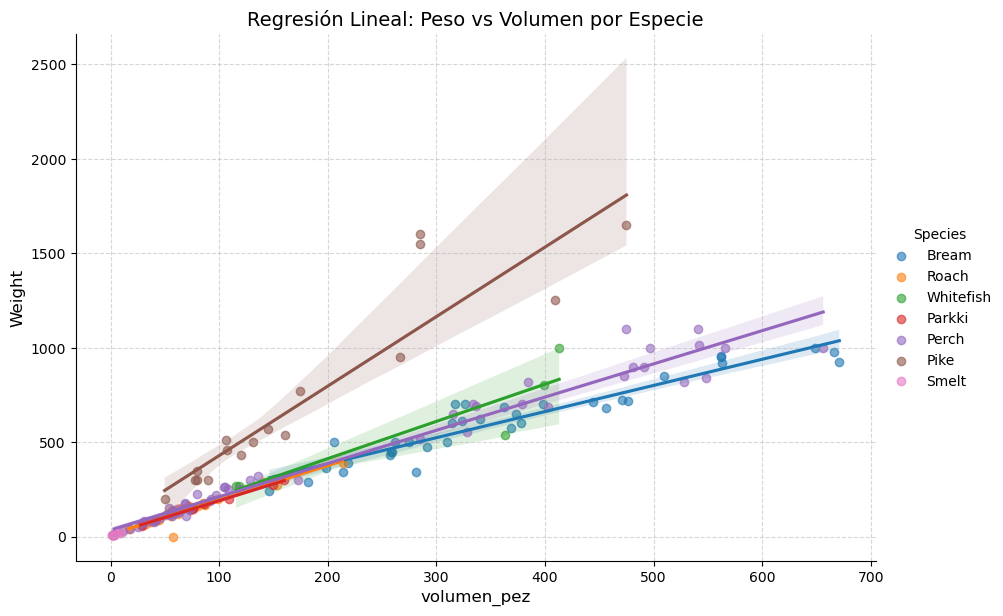

In [34]:
g = sns.lmplot(
    data=df, 
    x='volumen_pez', 
    y='Weight', 
    hue='Species',       # Separa por especie con un color distinto
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.6} # Transparencia de los puntos reales
)

# Personalización del gráfico
plt.title('Regresión Lineal: Peso vs Volumen por Especie', fontsize=14)
plt.xlabel('volumen_pez', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
"""
Al segmentar la regresión lineal por especie, se observa que la relación entre volumen y peso varía según la 
morfología de cada tipo de pez. Esto se evidencia en las distintas pendientes de las líneas rectas: especies 
más robustas presentan pendientes más pronunciadas (mayor ganancia de peso por unidad de volumen) que las 
especies alargadas. Como resultado, la dispersión de los datos disminuye sustancialmente y la precisión 
predictiva del modelo ($R^2$) se incrementa para cada grupo.
"""

In [35]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width',
       'volumen_pez'],
      dtype='object')

In [36]:
df[['Height','Width']]

,Height,Width
0,11.5200,4.0200
1,12.4800,4.3056
2,12.3778,4.6961
3,12.7300,4.4555
4,12.4440,5.1340
...,...,...
154,2.0904,1.3936
155,2.4300,1.2690
156,2.2770,1.2558
157,2.8728,2.0672


In [39]:
"""
5. Construye un modelo de regresión que relacione dos o más variables con el peso de
los peces. Realiza una breve evaluación del modelo
"""

# Definir variables predictoras (X) y variable de respuesta (y)
X = df[['Height','Width']]
y = df['Weight']

# Codificar la variable categórica 'sex' usando get dummies
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

# Paso 2: Agregar una constante (intercepto) a las variables predictoras
X_encoded = sm.add_constant(X_encoded)

# Paso 3: Crear el modelo de regresión lineal
model = sm.OLS(y, X_encoded).fit()

# Paso 4: Obtener resultados del modelo
results = model.summary()

predictions = model.predict(X_encoded)

# Calcular el Error Cuadrático Medio (MSE)
mse = ((y - predictions) ** 2).mean()

# Calcular el Error Cuadrático Medio Explicado (EMSE)
emse = mse / ((y - y.mean()) ** 2).mean()

# Obtener el valor R² del modelo
r2 = model.rsquared

print(results)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Error Mean Squared Explicado (EMSE): {emse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     288.4
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           3.91e-53
Time:                        01:52:32   Log-Likelihood:                -1037.1
No. Observations:                 159   AIC:                             2080.
Df Residuals:                     156   BIC:                             2089.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -433.5757     37.075    -11.694      0.0

In [ ]:
"""
El modelo presenta un ajuste moderado alto con 78,7% lo que confirma que las dimensiones fisicas del pex tienen 
una relacion directa importante con su peso. Ademas, la prueba F (p<0.001) demuestra que el modelo en su conjunto 
es estadisticamente significativo.
La variable width es el predisctor dominante y sigmnificativo aportando la mayor capacidad explicatica del modelo.
la variable height no es relevante en este modelo lineal p=0.342 > 0.05 por lo que no aporta valor estadistico 
cuando ya se conoce el año del pez.
Para optimizar el rendimiento y la validez estadistica del analisis, se sugiere eliminar la variable height y 
evaluar una transformacion logaritmica en las varianlrs segmentacion por especie, lo que corregira la asimetria 
de los errores y mejorara la precision de las predicciones.
"""